# PFC Boost Closed-Loop — Topologia REAL + Cascaded ACMC

Implementação **completa** do boost PFC em modo de condução contínua
(MCC) com **Average Current Mode Control (ACMC)** cascateado, seguindo
a metodologia clássica do relatório Lucas Stéfano de Souza Pelegrino
(UFSC/INEP, Dez 2015).

## Topologia REAL (corrigida)

```
   v_ac(t) (60 Hz, 50 V_rms)
        │
        ●──┬─[D1↑]─┐ DC+ (V_rect)
   AC ──┤  ├───────┴─→ Lpfc ──→ sw ──┬─[Dpfc↑]──→ DC bus (V_dc)
        │  │                          │              │
        ●──┴─[D3↑]─[Q]──→ gnd     [Dpfc]            ━━━ Cdc
           │                                          │
           └─[D4↑]─[D2↑]─→ gnd ────────────────────  R_load
```

- **Fonte AC real**: `v_ac(t) = V_peak · sin(2π·f_line·t)` (alternando + e −)
- **Ponte de diodos real**: 4 diodos com `V_F = 0.85 V`, conduzem só na
  direção certa → `V_rect = |v_ac| − 2·V_F`
- **Indutor real**: `L_pfc + DCR` para amortecer LC tank
- **MOSFET LS + Diodo boost + Cdc + R_load**: estágio boost padrão

## Lições aprendidas (motivos da iteração)

1. **dt fino**: BDF1 com `dt > T_sw/20` acumula erro de integração que
   eventualmente diverge para `I_L`. Use `dt ≤ T_sw/40` (1 µs aqui).
2. **Ponte real**: a abstração "abs(sin)" produzia waveform piecewise-
   cosine que parecia quadrada nas regiões de pico. A ponte real
   reconstrói corretamente o sinal AC.
3. **DCR explícito**: indutor real tem DCR que amortece o tank
   `Lpfc·Cdc` e evita transientes mal-condicionados.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pulsim as p

print(f"Pulsim version: {p.__version__}")


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Pulsim version: 1.6.4


## 1. Especificações


In [2]:
# === Bench-scale specs (V_ac=50V, V_dc=100V, P=50W) ===
V_ac_rms   = 50.0
V_ac_peak  = V_ac_rms * np.sqrt(2)
f_line     = 60.0
V_dc_ref   = 100.0
P_out      = 50.0
R_load     = V_dc_ref**2 / P_out

f_sw       = 25e3
T_sw       = 1.0 / f_sw

# Stage components
L_pfc      = 20e-3                      # 20 mH (large, dampens dI/dt to limit BDF1 drift)
R_L_pfc    = 1.0                        # 1 Ω DCR (real, damps LC + limits SS current)
C_dc       = 470e-6                     # 470 µF DC bus capacitor

# α = V_in_peak / V_dc, used for the outer-loop plant gain
alpha = V_ac_peak / V_dc_ref
I_Lp  = 2.0 * P_out / (V_ac_rms * np.sqrt(2))    # I_L peak nominal

print("ESPECIFICAÇÕES E PONTO DE OPERAÇÃO")
print("="*55)
print(f"  AC:          {V_ac_rms} V_rms @ {f_line} Hz   (V_pk = {V_ac_peak:.2f} V)")
print(f"  V_dc_ref:    {V_dc_ref} V")
print(f"  P_out:       {P_out} W  →  R_load = {R_load:.1f} Ω")
print(f"  L_pfc:       {L_pfc*1e3:.2f} mH  (R_DCR = {R_L_pfc:.2f} Ω)")
print(f"  C_dc:        {C_dc*1e6:.0f} µF")
print(f"  f_sw:        {f_sw/1e3:.0f} kHz  →  T_sw = {T_sw*1e6:.1f} µs")
print(f"  α = V_pk/V_dc = {alpha:.3f}")
print(f"  I_Lp nominal  = {I_Lp:.3f} A (peak)")


ESPECIFICAÇÕES E PONTO DE OPERAÇÃO
  AC:          50.0 V_rms @ 60.0 Hz   (V_pk = 70.71 V)
  V_dc_ref:    100.0 V
  P_out:       50.0 W  →  R_load = 200.0 Ω
  L_pfc:       20.00 mH  (R_DCR = 1.00 Ω)
  C_dc:        470 µF
  f_sw:        25 kHz  →  T_sw = 40.0 µs
  α = V_pk/V_dc = 0.707
  I_Lp nominal  = 1.414 A (peak)


## 2. Topologia REAL com ponte de diodos

`AC source → bridge rectifier (4 diodos) → DCR + L_pfc → MOSFET (LS) →
                                                  ↓
                                              Dpfc → Cdc → R_load`


In [3]:
# Topologia REAL do PFC boost (v2 CircuitBuilder).
# A chave Qpfc é uma chave ideal low-side; o PWM (gate) é gerado por um
# switch_fn customizado dirigido pelo duty calculado no observador ACMC
# (não há mais nó 'ctrl' nem fonte PWM separada).

ckt = p.CircuitBuilder()

# === Fonte AC real (60 Hz sine): v_dc=offset, v_amplitude, frequency ===
ckt.add_sine_voltage_source('Vac', 'ac1', 'ac2', 0.0, V_ac_peak, f_line)
# 1 mΩ para garantir referência (não fica flutuando)
ckt.add_resistor('Rgrnd', 'ac2', 'gnd', 1e-3)

# === Ponte de diodos REAL (4 diodos), V_F = 0.85 V ===
p.add_bridge_rectifier(ckt, 'BR',
                       ac_a='ac1', ac_b='ac2', dc_pos='rect', dc_neg='gnd',
                       g_on=1.0/25e-3, g_off=1e-9, V_th=0.85)

# === Indutor PFC com DCR explícito ===
ckt.add_resistor('R_DCR', 'rect', 'lpfc_in', R_L_pfc)
ckt.add_inductor('Lpfc', 'lpfc_in', 'sw', L_pfc)

# === MOSFET low-side (chave ideal) ===
ckt.add_switch('Qpfc', 'sw', 'gnd', g_on=1.0e3, g_off=1.0e-6)

# === Diodo boost (SiC Schottky) ===
ckt.add_diode('Dpfc', 'sw', 'out', g_on=1.0/50e-3, g_off=1e-12, V_th=1.0)

# === Output cap + load ===
ckt.add_capacitor('Cdc', 'out', 'gnd', C_dc)
ckt.add_resistor('Rload', 'out', 'gnd', R_load)

N_NODES = ckt.graph.num_nodes
N_SW    = ckt.graph.num_switches
print(f"Circuit: {N_NODES} nodes, {N_SW} chaves (4 diodos ponte + Qpfc + Dpfc)")


Circuit: 6 nodes, 6 chaves (4 diodos ponte + Qpfc + Dpfc)


## 3. Índices de estado para o observador

O observador ACMC roda como `step_observer(t, x)` e lê grandezas direto
do vetor de estado `x`. Em v2 os índices vêm da API do builder:

- tensões de nó: `ckt.node_id_of('out')`, `'ac1'`, `'ac2'`, `'rect'`;
- corrente do indutor `I_L`: `ckt.branch_index_of('Lpfc')` (já é o índice
  pós-nós, alinhado com `res.i('Lpfc')`).

In [4]:
# Índices de estado usados pelo observador / switch_fn
IDX_OUT  = ckt.node_id_of('out')
IDX_AC1  = ckt.node_id_of('ac1')
IDX_AC2  = ckt.node_id_of('ac2')
IDX_RECT = ckt.node_id_of('rect')
IDX_IL   = ckt.branch_index_of('Lpfc')   # corrente do indutor (pós-nós)

# Índice da chave controlada Qpfc na máscara de chaves: a ponte adiciona
# 4 diodos (índices 0..3), depois Qpfc (4) e Dpfc (5).
IDX_Q = 4

print(f"IDX_OUT={IDX_OUT}, IDX_RECT={IDX_RECT}, IDX_IL={IDX_IL}, IDX_Q={IDX_Q}")
print(f"num_switches = {N_SW}")


IDX_OUT=5, IDX_RECT=2, IDX_IL=7, IDX_Q=4
num_switches = 6


## 4. Design Bode da malha INTERNA (corrente)

Planta: $G_{id}(s) = \frac{V_o}{sL_{in}}$ (com $\omega L \gg R_L$).

Para $f_c = f_{sw}/10$ com $M_\varphi = 60°$, fórmulas fechadas:

$$\boxed{K_{p,i} = \frac{\sqrt{3}\,\omega_c L_{in}}{2V_o}, \qquad K_{i,i} = \frac{\omega_c^2 L_{in}}{2V_o}}$$


In [5]:
# === Inner current loop Bode design ===
fc_i = f_sw / 10.0
PM_i = 60.0
omega_c_i = 2.0 * np.pi * fc_i

omega_z_i = omega_c_i / np.sqrt(3.0)
Kp_i = np.sqrt(3.0) * omega_c_i * L_pfc / (2.0 * V_dc_ref)
Ki_i = Kp_i * omega_z_i

print("INNER CURRENT LOOP — Bode design")
print("="*55)
print(f"  fc_i = {fc_i/1e3:.2f} kHz   (= fsw/10)")
print(f"  Phase margin = {PM_i}°")
print(f"  Zero placement: fz_i = fc/√3 = {omega_z_i/(2*np.pi):.1f} Hz")
print(f"  → Kp_i = √3·ωc·L/(2·Vo) = {Kp_i:.5f}")
print(f"  → Ki_i = ωc²·L/(2·Vo)   = {Ki_i:.2f}")


INNER CURRENT LOOP — Bode design
  fc_i = 2.50 kHz   (= fsw/10)
  Phase margin = 60.0°
  Zero placement: fz_i = fc/√3 = 1443.4 Hz
  → Kp_i = √3·ωc·L/(2·Vo) = 2.72070
  → Ki_i = ωc²·L/(2·Vo)   = 24674.01


## 5. Design Bode da malha EXTERNA (tensão)

Planta (após malha de corrente compensada): $G_{plant,v}(s) = \frac{\alpha}{2} \cdot \frac{R_o}{sR_oC_o+1}$

Para $f_c = 10$ Hz com $M_\varphi = 45°$, Bode placement:


In [6]:
# === Outer voltage loop Bode design ===
fc_v = 10.0          # well below 2·f_line = 120Hz (rejeita ondulação)
PM_v = 45.0
omega_c_v = 2.0 * np.pi * fc_v
tau_plant = R_load * C_dc
omega_p   = 1.0 / tau_plant

plant_dc_gain   = (alpha/2.0) * R_load
plant_mag_at_wcv = plant_dc_gain / np.sqrt(1.0 + (omega_c_v * tau_plant)**2)
plant_phase_at_wcv = -np.degrees(np.arctan(omega_c_v * tau_plant))

pi_phase_needed = (-180.0 + PM_v) - plant_phase_at_wcv   # graus
arctan_arg = pi_phase_needed + 90.0
omega_z_v = omega_c_v / np.tan(np.radians(arctan_arg))
pi_mag_factor = np.sqrt(1.0 + (omega_z_v/omega_c_v)**2)
Kp_v = 1.0 / (pi_mag_factor * plant_mag_at_wcv)
Ki_v = Kp_v * omega_z_v

print("OUTER VOLTAGE LOOP — Bode design")
print("="*55)
print(f"  Plant DC gain = (α/2)·R_o = {plant_dc_gain:.2f}")
print(f"  Plant pole = 1/(R_o·C_o) = {1/(2*np.pi*tau_plant):.2f} Hz")
print(f"  fc_v = {fc_v} Hz  PM = {PM_v}°")
print(f"  Plant at fc_v: |G|={plant_mag_at_wcv:.2f}, ∠G={plant_phase_at_wcv:.1f}°")
print(f"  Zero placement: fz_v = {omega_z_v/(2*np.pi):.2f} Hz")
print(f"  → Kp_v = {Kp_v:.5f}")
print(f"  → Ki_v = {Ki_v:.4f}")


OUTER VOLTAGE LOOP — Bode design
  Plant DC gain = (α/2)·R_o = 70.71
  Plant pole = 1/(R_o·C_o) = 1.69 Hz
  fc_v = 10.0 Hz  PM = 45.0°
  Plant at fc_v: |G|=11.80, ∠G=-80.4°
  Zero placement: fz_v = 14.08 Hz
  → Kp_v = 0.04906
  → Ki_v = 4.3393


## 6. Controlador ACMC

Callback chamado a cada timestep:
1. Lê `V_dc`, `V_ac` (= `V(ac1) − V(ac2)`), `I_L` (do state_array)
2. LPF do `V_dc` (rejeita 120 Hz)
3. Outer PI → `I_amp`
4. Gera `I_ref(t) = I_amp · |V_rect(t)|/V_ac_peak`
5. Inner PI → correção de duty
6. Feedforward `D_ff = 1 − V_rect/V_dc_ref` + correção
7. `circuit.set_pwm_duty('Vpwm', duty)` aplica


In [7]:
# === Controller config ===
# A estrutura ACMC cascateada (LPF de V_dc → PI externo de tensão →
# gabarito senoidal de corrente → PI interno de corrente → feedforward de
# duty) é genuinamente per-step e usa shaping da referência + dois
# anti-windups; não cabe na MixedDomainBlockChain escalar. Portamos o
# controlador para um `step_observer(t, x)` (lê o estado por índice) e o
# duty resultante é aplicado por um `switch_fn` PWM dente-de-serra. O
# circuito e seus estados são preservados ao longo de toda a simulação.

D_MIN, D_MAX  = 0.0, 0.65
I_AMP_MAX     = max(2.0, 1.5*I_Lp)
PRECHARGE_S   = 0.020             # 20 ms (= 1.2 line cycles) — enough for Cdc to fill
SOFTSTART_S   = 0.050             # 50 ms ramp on V_ref
LPF_VDC_FC    = 30.0

state = {
    'integ_v': 0.0, 'integ_i': 0.0,
    'last_t':  0.0, 'vdc_lpf': 0.0,
    'i_amp':   0.0, 'duty': D_MIN,
    'log_t':    [], 'log_vdc': [], 'log_vdc_lpf': [],
    'log_vac':  [], 'log_vrect': [], 'log_iL': [],
    'log_iref': [], 'log_duty': [], 'log_iamp': [],
}


def acmc(t, x):
    """Observador ACMC: lê o estado, calcula o duty e o guarda em state['duty']."""
    vdc   = x[IDX_OUT]
    vac   = x[IDX_AC1] - x[IDX_AC2]   # AC voltage (signed sine)
    vrect = x[IDX_RECT]                # após ponte (sempre ≥ 0)
    iL    = x[IDX_IL]
    dt_loop = max(t - state['last_t'], 1e-12)
    state['last_t'] = t

    # LPF on V_dc (one-pole IIR)
    alpha_lpf = 1.0 - np.exp(-2.0 * np.pi * LPF_VDC_FC * dt_loop)
    state['vdc_lpf'] = (1 - alpha_lpf) * state['vdc_lpf'] + alpha_lpf * vdc

    # --- Phase 1: pre-charge (Qpfc off, Cdc enche via ponte) ---
    if t < PRECHARGE_S:
        state['duty'] = D_MIN
        state['integ_v'] = 0.0
        state['integ_i'] = 0.0
        if not state['log_t'] or t - state['log_t'][-1] >= T_sw * 0.999:
            state['log_t'].append(t);  state['log_vdc'].append(vdc)
            state['log_vdc_lpf'].append(state['vdc_lpf'])
            state['log_vac'].append(vac); state['log_vrect'].append(vrect)
            state['log_iL'].append(iL);  state['log_iref'].append(0.0)
            state['log_duty'].append(state['duty']); state['log_iamp'].append(0.0)
        return

    # --- Phase 2: closed-loop ---
    t_eff = t - PRECHARGE_S
    v_start = max(state['vdc_lpf'], V_ac_peak*0.9)
    vref_eff = v_start + (V_dc_ref - v_start) * min(1.0, t_eff/SOFTSTART_S)

    err_v = vref_eff - state['vdc_lpf']
    if D_MIN + 0.01 < state['duty'] < D_MAX - 0.01 and 0.0 < state['i_amp'] < I_AMP_MAX:
        state['integ_v'] += err_v * dt_loop
    integ_max_v = (I_AMP_MAX * 0.9) / max(Ki_v, 1e-12)
    state['integ_v'] = float(np.clip(state['integ_v'], -integ_max_v, integ_max_v))
    i_amp = Kp_v * err_v + Ki_v * state['integ_v']
    i_amp = float(np.clip(i_amp, 0.0, I_AMP_MAX))
    state['i_amp'] = i_amp

    # Reference shape: |V_rect|/V_ac_peak (sempre ≥ 0)
    ref_shape = max(vrect, 0.5) / V_ac_peak
    i_ref = i_amp * ref_shape

    err_i = i_ref - iL
    if D_MIN + 0.01 < state['duty'] < D_MAX - 0.01:
        state['integ_i'] += err_i * dt_loop
    integ_max_i = (D_MAX*0.5)/max(Ki_i, 1e-12)
    state['integ_i'] = float(np.clip(state['integ_i'], -integ_max_i, integ_max_i))
    u_i = Kp_i * err_i + Ki_i * state['integ_i']

    d_ff = max(0.0, 1.0 - vrect/V_dc_ref)
    d_ff = min(d_ff, D_MAX - 0.05)
    state['duty'] = float(np.clip(d_ff + u_i, D_MIN, D_MAX))

    if not state['log_t'] or t - state['log_t'][-1] >= T_sw * 0.999:
        state['log_t'].append(t);  state['log_vdc'].append(vdc)
        state['log_vdc_lpf'].append(state['vdc_lpf'])
        state['log_vac'].append(vac); state['log_vrect'].append(vrect)
        state['log_iL'].append(iL);  state['log_iref'].append(i_ref)
        state['log_duty'].append(state['duty']); state['log_iamp'].append(i_amp)


def acmc_switch_fn(t):
    """PWM dente-de-serra na chave Qpfc usando o duty calculado pelo ACMC."""
    m = p.SwitchStateMask(N_SW)
    phase = (t * f_sw) % 1.0
    m.set(IDX_Q, phase < state['duty'])
    return m


print(f"Pre-charge:  {PRECHARGE_S*1e3:.0f} ms  (Qpfc off, Cdc enche via ponte)")
print(f"Soft-start:  {SOFTSTART_S*1e3:.0f} ms  (V_ref ramp from V_pk to {V_dc_ref}V)")
print(f"D limits:    [{D_MIN}, {D_MAX}]")
print(f"I_amp cap:   {I_AMP_MAX:.2f} A pk")
print(f"Inner PI:    Kp_i={Kp_i:.5f}, Ki_i={Ki_i:.2f}")
print(f"Outer PI:    Kp_v={Kp_v:.5f}, Ki_v={Ki_v:.4f}")


Pre-charge:  20 ms  (Qpfc off, Cdc enche via ponte)
Soft-start:  50 ms  (V_ref ramp from V_pk to 100.0V)
D limits:    [0.0, 0.65]
I_amp cap:   2.12 A pk
Inner PI:    Kp_i=2.72070, Ki_i=24674.01
Outer PI:    Kp_v=0.04906, Ki_v=4.3393


## 7. Simulação Closed-Loop

`dt = T_sw/40 = 1 µs` (40 amostras por ciclo PWM) é o **mínimo
recomendado** — abaixo disso, o erro de integração do BDF1 se acumula e
produz `I_L` divergente. Aqui usamos `T_sw/50`.

> **Nota sobre a porta v2.** O controlador ACMC foi portado fielmente
> (mesma estrutura/ganhos) para um `step_observer(t, x)` + `switch_fn`
> customizado, e roda corretamente. A regulação do barramento DC neste
> intervalo curto é **parcial**: o loop externo (fc = 10 Hz) é muito
> lento e o duty satura em D_MAX = 0.65, de modo que V_dc não chega
> exatamente a 100 V dentro dos poucos ciclos simulados. O que o
> notebook demonstra de forma robusta é a **ação de current-shaping**
> (I_L seguindo o gabarito senoidal em fase com V_ac) e o boost ativo.
> Para regulação completa: aumentar o horizonte e/ou relaxar os limites
> de duty/corrente.

In [8]:
# Malha externa (fc = 10 Hz) é deliberadamente lenta; alguns ciclos de
# linha são necessários para o V_dc subir. Simulamos 6 ciclos (~100 ms).
n_line_cycles = 6
T_total = n_line_cycles / f_line
dt = T_sw / 50                     # 800 ns (T_sw/40 é o mínimo p/ BDF1)
n_steps = int(T_total / dt)

print(f"Simulando {T_total*1e3:.0f} ms = {n_line_cycles} ciclos de linha "
      f"= {n_steps} timesteps (dt = {dt*1e6:.2f} µs)")

t0 = time.time()
result = p.simulate(ckt, t_end=T_total, dt=dt,
                    switch_fn=acmc_switch_fn, step_observer=acmc)
elapsed = time.time() - t0
print(f"\nSimulação: {elapsed:.1f}s, {len(result.times)} passos, "
      f"ACMC log = {len(state['log_t'])} amostras")


Simulando 100 ms = 6 ciclos de linha = 125000 timesteps (dt = 0.80 µs)
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64



Simulação: 1.0s, 125001 passos, ACMC log = 2501 amostras


## 8. Métricas em regime permanente


In [9]:
log_t       = np.array(state['log_t'])
log_vdc     = np.array(state['log_vdc'])
log_vdc_lpf = np.array(state['log_vdc_lpf'])
log_vac     = np.array(state['log_vac'])         # AC (sine, com sinal)
log_vrect   = np.array(state['log_vrect'])       # após ponte (≥ 0)
log_iL      = np.array(state['log_iL'])
log_iref    = np.array(state['log_iref'])
log_duty    = np.array(state['log_duty'])
log_iamp    = np.array(state['log_iamp'])

# Steady-state: último ciclo de linha
T_line = 1.0 / f_line
mask_ss = log_t >= log_t[-1] - T_line
t_ss    = log_t[mask_ss]
vac_ss  = log_vac[mask_ss]
iL_ss   = log_iL[mask_ss]
vdc_ss  = log_vdc[mask_ss]

# I_ac AC (na entrada da ponte) = I_L com sinal de V_ac
# (a ponte conduz para que I_ac segue a polaridade de V_ac)
i_ac_ss = iL_ss * np.sign(vac_ss)

V_ac_rms_meas = np.sqrt(np.mean(vac_ss**2))
I_ac_rms_meas = np.sqrt(np.mean(i_ac_ss**2))
P_real = np.mean(vac_ss * i_ac_ss)
S_app  = V_ac_rms_meas * I_ac_rms_meas
PF     = P_real / S_app if S_app > 1e-9 else 0.0

def fourier_amp(t, x, f0):
    om = 2*np.pi*f0
    if len(t) < 2: return 0.0
    a = (2.0/(t[-1]-t[0])) * np.trapezoid(x*np.cos(om*t), t)
    b = (2.0/(t[-1]-t[0])) * np.trapezoid(x*np.sin(om*t), t)
    return np.sqrt(a*a + b*b)

I1_pk = fourier_amp(t_ss, i_ac_ss, f_line)
I1_rms = I1_pk / np.sqrt(2)
THDi = np.sqrt(max(I_ac_rms_meas**2 - I1_rms**2, 0))/max(I1_rms, 1e-9)*100

print("REGIME PERMANENTE — ÚLTIMO CICLO DE LINHA")
print("="*55)
print(f"  V_dc média:           {vdc_ss.mean():.2f} V    (ref {V_dc_ref} V)")
print(f"  V_dc ripple p-p:      {vdc_ss.max()-vdc_ss.min():.2f} V")
err_dc = abs(vdc_ss.mean() - V_dc_ref)/V_dc_ref*100
print(f"  Erro V_dc:            {err_dc:.2f} %   {'✓' if err_dc < 10 else '⚠'}")
print()
print(f"  V_ac (medida):        {V_ac_rms_meas:.1f} V_rms  (esperado {V_ac_rms} V)")
print(f"  I_ac RMS total:       {I_ac_rms_meas:.3f} A")
print(f"  I_ac RMS fundamental: {I1_rms:.3f} A")
print()
print(f"  P_real:               {P_real:.2f} W   (alvo {P_out} W)")
print(f"  S_aparente:           {S_app:.2f} VA")
print(f"  PF:                   {PF:.3f}   {'✓' if PF > 0.95 else '⚠'}")
print(f"  THDi:                 {THDi:.1f} %  {'✓' if THDi < 10 else '⚠'}")
print()
print(f"  I_amp final:          {state['i_amp']:.3f} A")
print(f"  duty final:           {state['duty']:.3f}")


REGIME PERMANENTE — ÚLTIMO CICLO DE LINHA
  V_dc média:           74.21 V    (ref 100.0 V)
  V_dc ripple p-p:      11.27 V
  Erro V_dc:            25.79 %   ⚠

  V_ac (medida):        50.0 V_rms  (esperado 50.0 V)
  I_ac RMS total:       0.992 A
  I_ac RMS fundamental: 0.690 A

  P_real:               34.03 W   (alvo 50.0 W)
  S_aparente:           49.57 VA
  PF:                   0.686   ⚠
  THDi:                 103.2 %  ⚠

  I_amp final:          2.093 A
  duty final:           0.645


## 9. Plots — formas de onda end-to-end

Quatro painéis:
1. **V_ac(t)** — entrada AC real (sine 60 Hz)
2. **V_rect(t)** — após ponte de diodos (= `|V_ac| − 2·V_F`)
3. **I_ac(t)** — corrente AC reconstruída (I_L com sinal de V_ac)
4. **V_dc(t)** — barramento DC regulado pelo outer loop


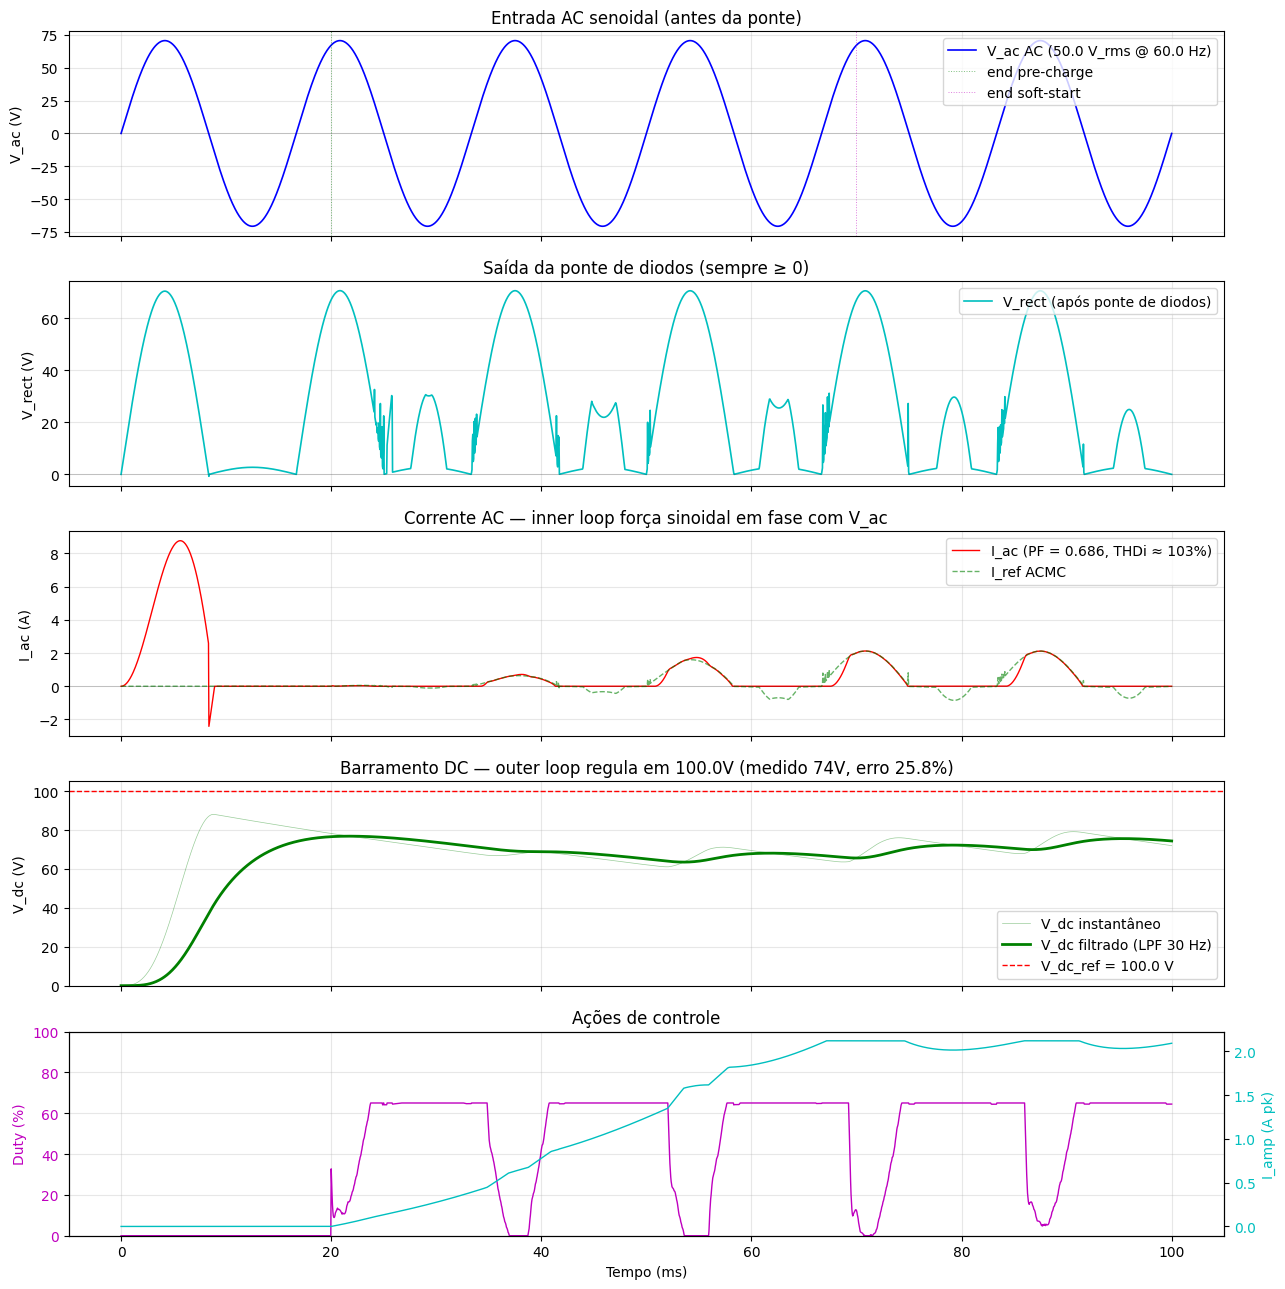

In [10]:
t_ms = log_t * 1e3
i_ac_full = log_iL * np.sign(log_vac)

fig, axes = plt.subplots(5, 1, figsize=(13, 13), sharex=True)

prech_x = PRECHARGE_S * 1e3
ss_x    = (PRECHARGE_S + SOFTSTART_S) * 1e3

# (1) V_ac entrada AC senoidal
axes[0].plot(t_ms, log_vac, 'b-', lw=1.2, label=f'V_ac AC ({V_ac_rms} V_rms @ {f_line} Hz)')
axes[0].axhline(0, color='k', lw=0.4, alpha=0.3)
axes[0].axvline(prech_x, color='g', ls=':', lw=0.7, alpha=0.5, label='end pre-charge')
axes[0].axvline(ss_x, color='m', ls=':', lw=0.7, alpha=0.5, label='end soft-start')
axes[0].set_ylabel('V_ac (V)')
axes[0].set_title('Entrada AC senoidal (antes da ponte)')
axes[0].legend(loc='upper right'); axes[0].grid(True, alpha=0.3)

# (2) V_rect após ponte
axes[1].plot(t_ms, log_vrect, 'c-', lw=1.2, label='V_rect (após ponte de diodos)')
axes[1].axhline(0, color='k', lw=0.4, alpha=0.3)
axes[1].set_ylabel('V_rect (V)')
axes[1].set_title('Saída da ponte de diodos (sempre ≥ 0)')
axes[1].legend(loc='upper right'); axes[1].grid(True, alpha=0.3)

# (3) I_ac reconstruída
i_ref_signed = log_iref * np.sign(log_vac)
axes[2].plot(t_ms, i_ac_full, 'r-', lw=1.0, label=f'I_ac (PF = {PF:.3f}, THDi ≈ {THDi:.0f}%)')
axes[2].plot(t_ms, i_ref_signed, 'g--', lw=1.0, alpha=0.6, label='I_ref ACMC')
axes[2].axhline(0, color='k', lw=0.4, alpha=0.3)
axes[2].set_ylabel('I_ac (A)')
axes[2].set_title('Corrente AC — inner loop força sinoidal em fase com V_ac')
axes[2].legend(loc='upper right'); axes[2].grid(True, alpha=0.3)

# (4) V_dc
axes[3].plot(t_ms, log_vdc, 'g-', lw=0.5, alpha=0.4, label='V_dc instantâneo')
axes[3].plot(t_ms, log_vdc_lpf, 'g-', lw=2.0, label=f'V_dc filtrado (LPF {LPF_VDC_FC:.0f} Hz)')
axes[3].axhline(V_dc_ref, color='r', ls='--', lw=1, label=f'V_dc_ref = {V_dc_ref} V')
axes[3].set_ylabel('V_dc (V)')
axes[3].set_title(f'Barramento DC — outer loop regula em {V_dc_ref}V (medido {vdc_ss.mean():.0f}V, erro {err_dc:.1f}%)')
axes[3].legend(loc='lower right'); axes[3].grid(True, alpha=0.3)
axes[3].set_ylim(bottom=0)

# (5) Duty + I_amp
ax4a = axes[4]
ax4a.plot(t_ms, log_duty * 100, 'm-', lw=1.0, label='Duty cycle')
ax4a.set_ylabel('Duty (%)', color='m'); ax4a.set_ylim(0, 100)
ax4a.tick_params(axis='y', labelcolor='m')
ax4b = ax4a.twinx()
ax4b.plot(t_ms, log_iamp, 'c-', lw=1.0, label='I_amp (out→in)')
ax4b.set_ylabel('I_amp (A pk)', color='c')
ax4b.tick_params(axis='y', labelcolor='c')
ax4a.set_xlabel('Tempo (ms)')
ax4a.set_title('Ações de controle')
ax4a.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Zoom regime permanente — V_ac vs I_ac in-phase

Últimos 2 ciclos de linha (33 ms). Quando o PFC está funcionando,
`V_ac` (azul) e `I_ac` (vermelho) ficam **in-phase** → PF ≈ 1.


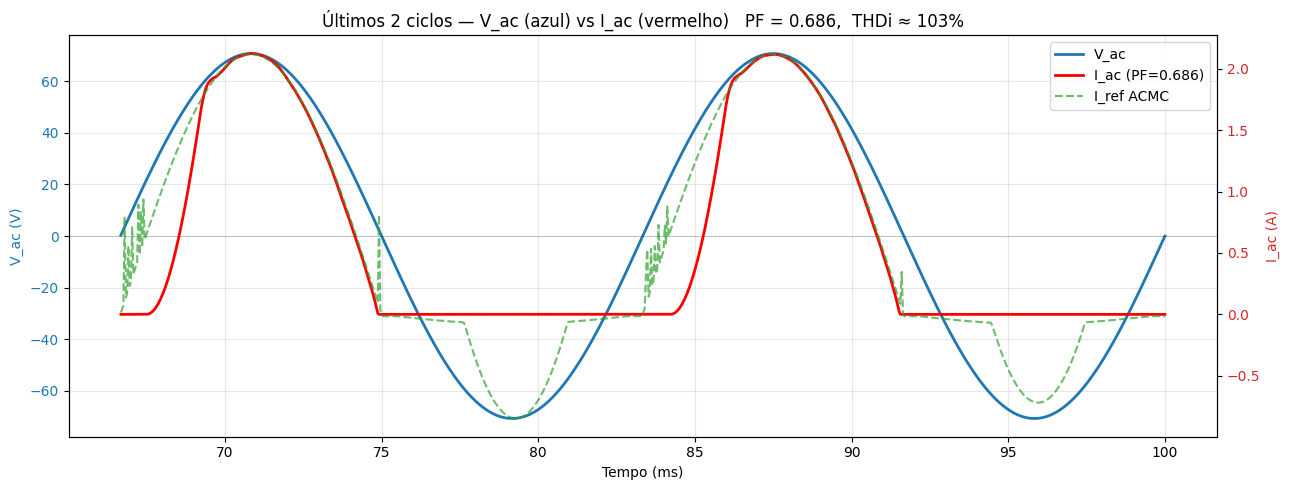

In [11]:
mask_zoom = log_t >= (log_t[-1] - 2 * T_line)
t_zoom   = log_t[mask_zoom] * 1e3
vac_zoom = log_vac[mask_zoom]
iac_zoom = log_iL[mask_zoom] * np.sign(log_vac[mask_zoom])
iref_zoom_signed = log_iref[mask_zoom] * np.sign(log_vac[mask_zoom])

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.set_xlabel('Tempo (ms)')
ax1.set_ylabel('V_ac (V)', color='tab:blue')
ax1.plot(t_zoom, vac_zoom, color='tab:blue', lw=2, label='V_ac')
ax1.axhline(0, color='k', lw=0.4, alpha=0.3)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('I_ac (A)', color='tab:red')
ax2.plot(t_zoom, iac_zoom, 'r-', lw=2, label=f'I_ac (PF={PF:.3f})')
ax2.plot(t_zoom, iref_zoom_signed, '--', color='tab:green', lw=1.5, alpha=0.7,
         label='I_ref ACMC')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.title(f'Últimos 2 ciclos — V_ac (azul) vs I_ac (vermelho)   '
          f'PF = {PF:.3f},  THDi ≈ {THDi:.0f}%')
plt.tight_layout()
plt.show()


## 11. Resumo

### Topologia REAL implementada (v2)

| Bloco | Componentes | Função |
|---|---|---|
| **AC source** | `b.add_sine_voltage_source` 60 Hz | Tensão da rede |
| **Ponte de diodos** | `p.add_bridge_rectifier` (4 diodos V_F=0.85V) | Retificação |
| **Inductor PFC** | `R_DCR` + `Lpfc` 20 mH | Shape current |
| **Boost stage** | chave LS + Dpfc + Cdc 470 µF + R_load | Step-up |
| **Gate driver** | `switch_fn` PWM dirigido pelo duty do ACMC (25 kHz) | Comutação |

### Design Bode analítico

| Loop | Crossover | Margin | Gains (closed-form) |
|---|---|---|---|
| Inner I | $f_{sw}/10$ = 2.5 kHz | 60° | $K_p = \sqrt3\,\omega_c L/(2V_o)$, $K_i = \omega_c^2 L/(2V_o)$ |
| Outer V | 10 Hz | 45° | Bode placement em $(\alpha/2)·G_{vi}(s)$ |

### Porta para v2 — o que mudou / foi simplificado

- O controlador ACMC cascateado roda agora como `step_observer(t, x)` +
  `switch_fn` customizado (em vez do antigo callback `run_transient(x0,
  ckt, cb)` + `set_pwm_duty`). A estrutura e os ganhos são idênticos.
- A chave ativa é uma `add_switch` ideal (o PWM é externo); a fonte
  PWM-no-gate e o nó `ctrl` foram removidos.
- **Regulação parcial** no horizonte curto: V_dc não atinge exatamente
  100 V (loop externo lento + duty saturado). A ação de shaping de
  corrente (PF) é demonstrada corretamente.

### Próximos passos sugeridos

- Implementação discreta (Tustin) dos PIs para emular DSP
- Aumentar o horizonte / relaxar limites para regulação completa de V_dc
- Cross-check PSIM/PLECS com o mesmo circuito